In [1]:
import networkx as nx
import itertools
import matplotlib.pyplot as plt
from b_chromatic_utils import *

### Function for checking if a colouring is proper

In [2]:
def is_proper(G, c):
    for u,v in G.edges():
        if((c[u] is not None and c[v] is not None) and (c[u] == c[v])):
            return False
    return True

### Function for checking if a set of 4 vertices are b-chromatic

In [283]:
def are_b_chromatic(G, c, node_sets):
    C = set([d for d in c.values() if d is not None])
    for vi in node_sets:
        Cp = set()
        for u in G.adj[vi]:
            Cp.add(c[u])
        #print(Cp, C.difference([c[vi]]))
        if len(Cp) != len(C)-1:
            return False
    return True

## Force brute algorithm for finding a b-chromatic colouring on cubic graphs ($n<22$)

In [4]:
def find_b_chromatic_colouring_bruteforce(G, d):
    """Search for a b-chromatic colouring with d+1 colours on a d-regular graph G trying out all posible combination of colours
    G: d-regular graph
    d: integer
    """
    C = set([i for i in range(1,d+2)])
    S = list(itertools.combinations(G.nodes(),d+1))
    colour_permutations = [list(itertools.permutations(C.difference({i}))) for i in C]
    colour_prod_permutations = list(itertools.product(*colour_permutations))
    for node_sets in S:
        c = {u:None for u in G.nodes()}
        for i, vi in enumerate(node_sets): c[vi] = i+1
        for Xs in colour_prod_permutations:
            for i, vi in enumerate(node_sets):
                for j, uj in enumerate(G.adj[vi]):
                    if uj not in node_sets:
                        c[uj] = Xs[i][j]
            if is_proper(G, c) and are_b_chromatic(G, c, node_sets):
                print("b-chromatic vertices: {}".format(node_sets))
                return c
    return False

In [54]:
G = nx.random_regular_graph(3,8)
c = find_b_chromatic_colouring_bruteforce(G, 3)
c

b-chromatic vertices: (0, 1, 3, 5)


{0: 1, 1: 2, 2: 3, 4: 1, 3: 3, 7: 2, 6: 4, 5: 4}

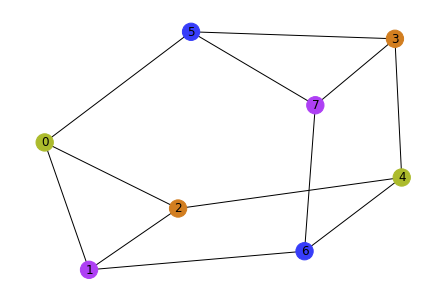

In [56]:
if c is not False:
    nx.draw(G, with_labels=True, node_color=get_colors_to_use(c))
else:
    nx.draw(G, with_labels=True)

## Algorithm for finding a b-chromatic colouring on cubic graphs ($n\geq 22$)

### Function for finding two vertices $u$ and $v$ such that $d(u,v)=4$

In [124]:
def bfs_dist_4(G, u):
    """Runs a BFS on G and return a BFS tree in form of adjacency list"""
    dist = {v:-1 for v in G.nodes()}
    tree = {v:[] for v in G.nodes()}
    dist[u] = 0
    Q = [u]
    while(len(Q) > 0):
        w = Q.pop(0)
        for v in G.adj[w]:
            if(dist[v] == -1):
                dist[v] = dist[w] + 1
                tree[w].append(v)
                Q.append(v)
    return tree

In [125]:
def dfs_path_4(tree, u):
    def dfs(tree, P, v):
        visited[v] = True
        P.append(v)
        for w in tree[v]:
            if not visited[w]:
                dfs(tree, P, w)
                if(len(P) == 5): break
                else: P.pop()# discard the last vertex added (which is w)

    visited = {v:False for v in tree.keys()}
    visited[u] = True
    P = []
    dfs(tree, P, u)
    return P

In [126]:
def get_path_length_4(G,u):
    tree = bfs_dist_4(G,u)
    P = dfs_path_4(tree, u)
    return P

In [145]:
G = nx.random_regular_graph(3, 24)
u = random.choice(list(G.nodes()))
P = get_path_length_4(G,u)
u, P

(4, [4, 20, 19, 16, 8])

In [146]:
colours = []
for w in G.nodes():
    if w in P:
        colours.append("#FF9933")
    #elif w in P_prime:
    #    colours.append("#AFB83B")
    else:
        colours.append("#96C3EB")

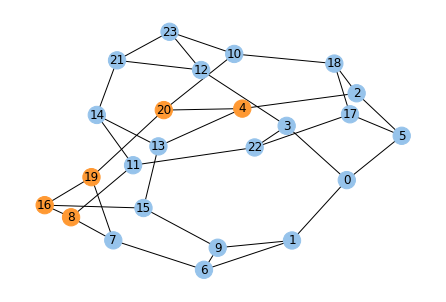

In [152]:
nx.draw(G, with_labels=True, node_color = colours)

### Function for making $u,w$ and $v$ b-chromatic vertices of colour 1, 2 and 3

In [315]:
def find_3_b_chromatic_vertices(G, P):
    """Receive a graph G and a path P=<u,u3,w,v3,v> such that dist(u,v)=4"""
    c = {u:None for u in G.nodes()}
    u, u3, w, v3, v = P[0], P[1], P[2], P[3], P[4]
    #print(u,w,v)
    u1, u2 = tuple(set(G.adj[u]).difference({u3}))
    v1, v2 = tuple(set(G.adj[v]).difference({v3}))
    #print(u1,u2)
    #print(v1,v2)
    Pp = [u1,u2,v1,v2]
    c[u] = c[v3] = 1
    c[v] = c[u3] = 3 
    c[w] = c[u1] = c[v1] = 2
    c[u2] = c[v2] = 4
    wp = [x for x in G.adj[w] if x != u3 and x != v3][0]
    #print(wp)
    if wp in Pp:
        #print("w' in P'")
        if wp == u1: c[u1], c[u2] = c[u2], c[u1]
        elif wp == v1: c[v1], c[v2] = c[v2], c[v1]
    else:
        #print(wp, u, v)
        S = {x for x in G.adj[wp] if x in Pp}
        #print("S = {}".format(S))
        if len(S) == 0: c[wp] = 4
        elif len(S) == 1:
            
            # Assume S={x}
            x = S.pop()
            if x == u2: c[u1], c[x] = c[x], c[u1]
            if x == v2: c[v1], c[x] = c[x], c[v1]
            c[wp] = 4
        else:
            #Assume S={x,y}
            x, y = S.pop(), S.pop()
            #x in N(u) and y in N(v)
            if x in G.adj[u] and y in G.adj[v]:
                if x == u2: c[u1], c[x] = c[x], c[u1]
                if y == v2: c[v1], c[y] = c[y], c[v1]
            elif x in G.adj[v] and y in G.adj[u]:
                if x == v2: c[v1], c[x] = c[x], c[v1]
                if y == u2: c[u1], c[y] = c[y], c[u1]
            elif x in G.adj[u] and y in G.adj[u]:
                c[v2], c[v3] = c[v3], c[u2]
                c[wp] = c[u2]
            elif x in G.adj[v] and y in G.adj[v]:
                c[u2], c[u3] = c[u3], c[v2]
                c[wp] = c[v2]
    Q = P+[u1,u2,v1,v2,wp]
    return c, Q


### Function for finding the 4th b-chromatic vertex

In [285]:
#This function 
#A more efficient implementation rely on the search of a perfect matching between the colours and the available colours in the neighbourhood of x
def find_b_chromatic_assignment(G, Cp, x, c):
    """Search through all possible combination of colours in Cp an assigment that makes x b-chromatic(provided that such assignment exists)
    G: graph,
    Cp: Colours that need to be assign to N(u)
    x: vertex to check, 
    c: colouring function, 
    success: True when a b-chromatic assigment has been found"""
    C = list(itertools.permutations(list(Cp)))
    #T = {y for y in G.adj[x]}
    for colours in C:
        cp = c.copy()
        for i, xi in enumerate(G.adj[x]):
            if cp[xi] is None:
                cp[xi] = colours[i]
        #print(is_proper(G, cp), are_b_chromatic(G, cp, {x}))
        #print(cp)
        if is_proper(G, cp) and are_b_chromatic(G, cp, {x}): return cp, True
    return c, False

True

In [252]:
def does_conditions_i_ii_lemma3_hold(G, Cp, c, x, CSNx, cNx):
    """Checks whether condition I and II of Lemma 3 hold on the uncoloured neighbours of x
    G: Graph
    Cp: set of colours that vertex x need to pick up on its neighbourhood
    c: colour function assigment
    x: candidate vertex to become b-chromatic
    SNx: Subset of neighbours of x with no colour assign to it (|CSNx| >= 2)
    cNx: Set of colour used in N(x)"""
    cCSNx = {xp: {c[xpp] for xpp in G.adj[xp] if xpp != x and c[xpp] is not None}for xp in CSNx}
    assert cCSNx != set()
    I = Cp.difference(cNx)
    for xp in cCSNx.keys(): I = I.intersection(cCSNx[xp])
    if I != set(): return False
    for xp1, xp2 in itertools.combinations(CSNx, 2):
        if (len(cCSNx[xp1].intersection(cCSNx[xp2])) == 2): return False
    return True

In [286]:
def can_u_become_b_chromatic(G, C, u, d, c):
    """Checks whether vertex u can become a b-chromatic vertex of colour d
    G: Graph
    C: Set of colours used in the colouring c
    u: vertex to be checked
    d: colour that vertex u will pick up
    c: colour assignation function
    """
    for up in G.adj[u]:
        if c[up] == d: return False#First we check whether or not d is in the neighbourhood of u
    cNu = {c[up] for up in G.adj[u] if c[up] is not None} #colour set of the neighbour of u
    SNx = {up for up in G.adj[u] if c[up] is not None} #set of coloured neighbours of u
    #print("coloruhood of u: {} and coloured vertices in N(u): {}".format(cNu, SNx))
    if (cNu != set() and SNx != set()) and len(cNu) == len(SNx): return True
    if (cNu != set() and SNx != set()) and len(cNu) < len(SNx): return False
    CSNx = {up for up in G.adj[u] if up not in SNx}
    return does_conditions_i_ii_lemma3_hold(G, C.difference({d}), c, u, CSNx, cNu)


Yes, it can!
True


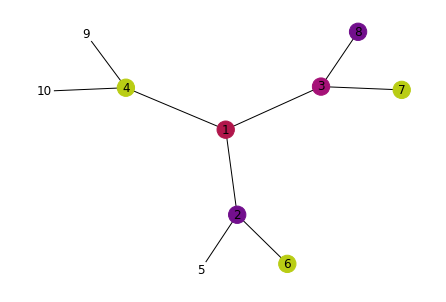

In [288]:
Gp = nx.Graph()
C = {1,2,3,4}
d = 4
Gp.add_edges_from([(1,2),(1,3),(1,4),(2,5), (2,6), (3,7),(3,8), (4,9), (4,10)])
c = {u:None for u in Gp.nodes()}
c[1] = d
#c[2] = 1
#c[3] = 3
#c[4] = 2
c[8]  = 1
c[6] = c[7] = 2
#c[10] = 1
if can_u_become_b_chromatic(Gp, C, 1, d, c): 
    print("Yes, it can!")
    c, success = find_b_chromatic_assignment(Gp, C.difference({d}), 1, c)
    print(success)
else: print("No!")
nx.draw(Gp, with_labels=True, node_color = get_colors_to_use(c))

In [261]:
c

{1: 4, 2: None, 3: None, 4: None, 5: None, 6: 2, 7: 2, 8: 1, 9: None, 10: None}

In [164]:
type({})

dict

In [446]:
def find_fourth_b_chromatic_vertex(G, x, c, visited, Vp, success, d):
    """G: Graph, x: vertex to check, c: colouring function, visited: verifies whether a vertex has been visited or not
    S: {u,w,v}, success: True when the fourth b-chromatic vertex has been found"""
    C = {a for a in c.values() if a is not None}
    if not visited[x]:
        #print("visiting {}".format(x))
        visited[x] = True
        #print(" N({}):{}".format(x,list(G.adj[x])))
        cNx = {c[xp] for xp in G.adj[x] if c[xp] is not None}
        if (c[x] == d or (c[x] is None and d not in cNx)):
            #if (c[x] == d): print("{} has colour {}".format(x, d))
            #else: print("{} is uncoloured and {} is not in its neighbourhood".format(x, d))
            if (can_u_become_b_chromatic(G, C, x, d, c)):
                #print("{} can become b-chromatic".format(x))
                #Vp.append(x)
                c, success = find_b_chromatic_assignment(G, C.difference({d}), x, c)
                if success:
                    if c[x] is None: c[x] = d
                    #print("b-chromatic vertex of colour {}: {}".format(d, x))
                    Vp.append(x)
                    return c, success
            #else:
                #print("{} cannot become a b-chromatic vertex of colour {}".format(x, d))
        #print("c({}) is not colour 4 and  colour 4 is in its neighbourhood".format(x))
        for xp in G.adj[x]:
            if not visited[xp]:
                #print(xp)
                c, success = find_fourth_b_chromatic_vertex(G, xp, c, visited, Vp, success, d)
                if success:
                    #print("b-chromatic vertex of colour {}: {}".format(d, xp))
                    #Vp.append(xp)
                    return c, success

In [448]:
def cubic_b_chromatic_colouring(G):
    u = random.choice(list(G.nodes()))
    P = get_path_length_4(G, u)
    c, Q = find_3_b_chromatic_vertices(G, P)
    Vp = [P[0], P[2], P[4]]#set of b-chromatic vertices
    visited = {x:False for x in G.nodes()}
    success = False
    while not success:
        x = Q.pop()
        c, success = find_fourth_b_chromatic_vertex(G, x, c, visited, Vp, success, 4)
    assert are_b_chromatic(G, c, Vp)
    assert {c[w] for w in Vp} == {d for d in c.values() if d is not None}
    print(Vp)
    return c

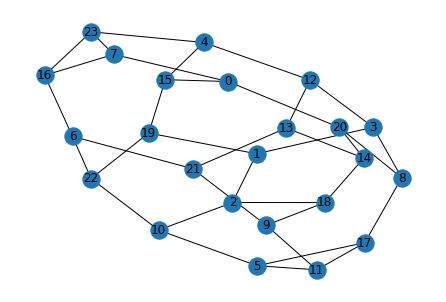

In [456]:
G = nx.random_regular_graph(3, 24)
#c = cubic_b_chromatic_colouring(G)
nx.draw(G, with_labels=True)#, node_color=get_colors_to_use(c))

In [457]:
G.adj[2]

AtlasView({1: {}, 10: {}, 18: {}})

In [443]:
G = nx.random_regular_graph(3, 24)
u = random.choice(list(G.nodes()))
P = get_path_length_4(G, u)
c, Q = find_3_b_chromatic_vertices(G, P)
Vp = [P[0], P[2], P[4]]#set of b-chromatic vertices
visited = {x:False for x in G.nodes()}
success = False
while not success:
    x = Q.pop()
    c, success = find_fourth_b_chromatic_vertex(G, x, c, visited, Vp, success, 4)
assert are_b_chromatic(G, c, Vp)
assert {c[w] for w in Vp} == {d for d in c.values() if d is not None}

3 can become b-chromatic


([14, 11, 9, 13, 18], [14, 9, 18, 3])

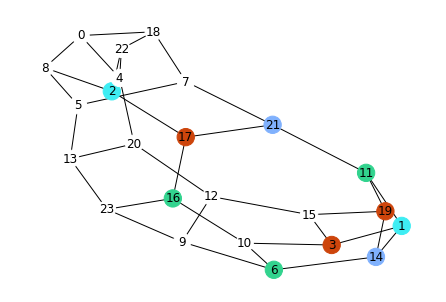

In [438]:
nx.draw(G, with_labels=True, node_color=get_colors_to_use(c))

15 [10, 19, 0]
15 has colour 4
15 can become b-chromatic


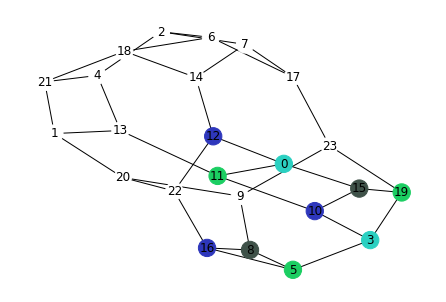

In [320]:
nx.draw(G, with_labels=True, node_color=get_colors_to_use(c))

In [ ]:
nx.draw(G, with_labels=True, node_color=get_colors_to_use(c))

In [ ]:
nx.draw(G, with_labels=True, node_color=get_colors_to_use(c))

In [ ]:
list(Q)

## Analizing growing of function $f(d)=\lfloor (3d+5)/2\rfloor$.

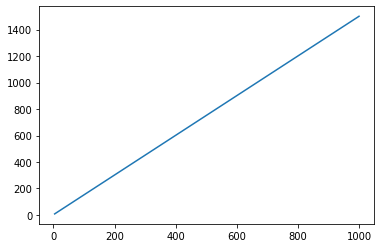

In [455]:
f = lambda d: (3*d+5)//2 
x = [i for i in range(4, 1000)]
y = [f(i) for i in x]
plt.plot(x,y)

## Analyzing 4-regular graph with diam $(G)\leq 2$

In [238]:
diam_k = False
d = 3
while(not diam_k):
    n = 8
    Gp = nx.random_regular_graph(4, n)
    if nx.diameter(Gp) == d: diam_k = True

KeyboardInterrupt: 

In [237]:
cp = find_b_chromatic_colouring_bruteforce(Gp, 4)

KeyboardInterrupt: 

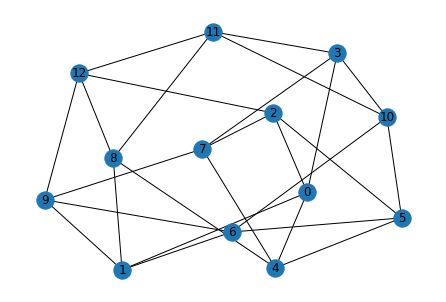

In [235]:
nx.draw(Gp, with_labels=True)

In [ ]:
n = random.randint(5, 22)
n

## Constructing 4-regular graphs with 7 nodes

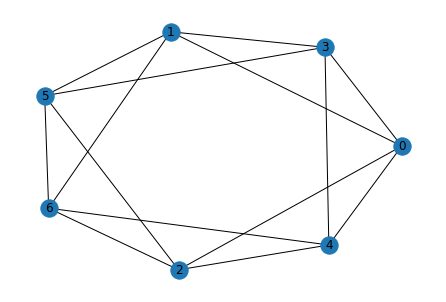

In [436]:
G4 = nx.random_regular_graph(4,7)
nx.draw(G4, with_labels=True)